In [1]:
import json
import math
import os
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.stats import spearmanr
from sklearn.metrics import r2_score
from torch_geometric.data import Data
from tqdm import tqdm

import barostat_parameters
from graph_utils import prepare_traj
from itpo_weights import DatasetType
from simulator_SA_cpu_test import Model as VelocityModel
from training_utils import freeze_normalizer
from utils import calc_p_ratio_box_tensor, get_rollout


/home/sergey/work/gnn/GNNInverseDesign/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def get_explicit_splits(
    registry_path: str,
    target_data_type: str,
    train_config: dict,
    val_config: dict,
    seed: int = 42,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Explicitly draws N training samples and M validation samples based on predefined P-ranges.
    Everything left over defaults to the Test set.
    """
    df = pd.read_csv(registry_path)
    pool_df = df[df["data_type"] == str(target_data_type)].copy()

    if pool_df.empty:
        raise ValueError(f"No data found for data_type: {target_data_type}")

    # 1. Sample Training Data
    train_candidates = pool_df[
        (pool_df["poisson_ratio"] >= train_config["p_min"])
        & (pool_df["poisson_ratio"] < train_config["p_max"])
    ]

    if len(train_candidates) < train_config["count"]:
        raise ValueError(
            f"Train requested {train_config['count']}, but only {len(train_candidates)} available in range."
        )

    train_df = train_candidates.sample(n=train_config["count"], random_state=seed)

    # Remove the selected training data from the master pool to prevent leakage
    pool_df = pool_df.drop(train_df.index)

    # 2. Sample Validation Data
    val_candidates = pool_df[
        (pool_df["poisson_ratio"] >= val_config["p_min"])
        & (pool_df["poisson_ratio"] < val_config["p_max"])
    ]

    if len(val_candidates) < val_config["count"]:
        raise ValueError(
            f"Val requested {val_config['count']}, but only {len(val_candidates)} available in range."
        )

    val_df = val_candidates.sample(n=val_config["count"], random_state=seed)

    # Remove the selected validation data from the master pool
    pool_df = pool_df.drop(val_df.index)

    # 3. The Rest is Testing
    test_df = pool_df.copy()

    return train_df, val_df, test_df


In [3]:
# Load the results
dataset_type = DatasetType.NodeOptimized # Match this to your actual enum string
main_directory = os.path.join("./cross_val", f"{dataset_type}", "MST")
results_path = os.path.join(main_directory, "monte_carlo_cv_results.pkl")
results = torch.load(results_path)
len(results)

20

### Plot training and validation losses

/tmp/ipykernel_9546/2894106867.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')


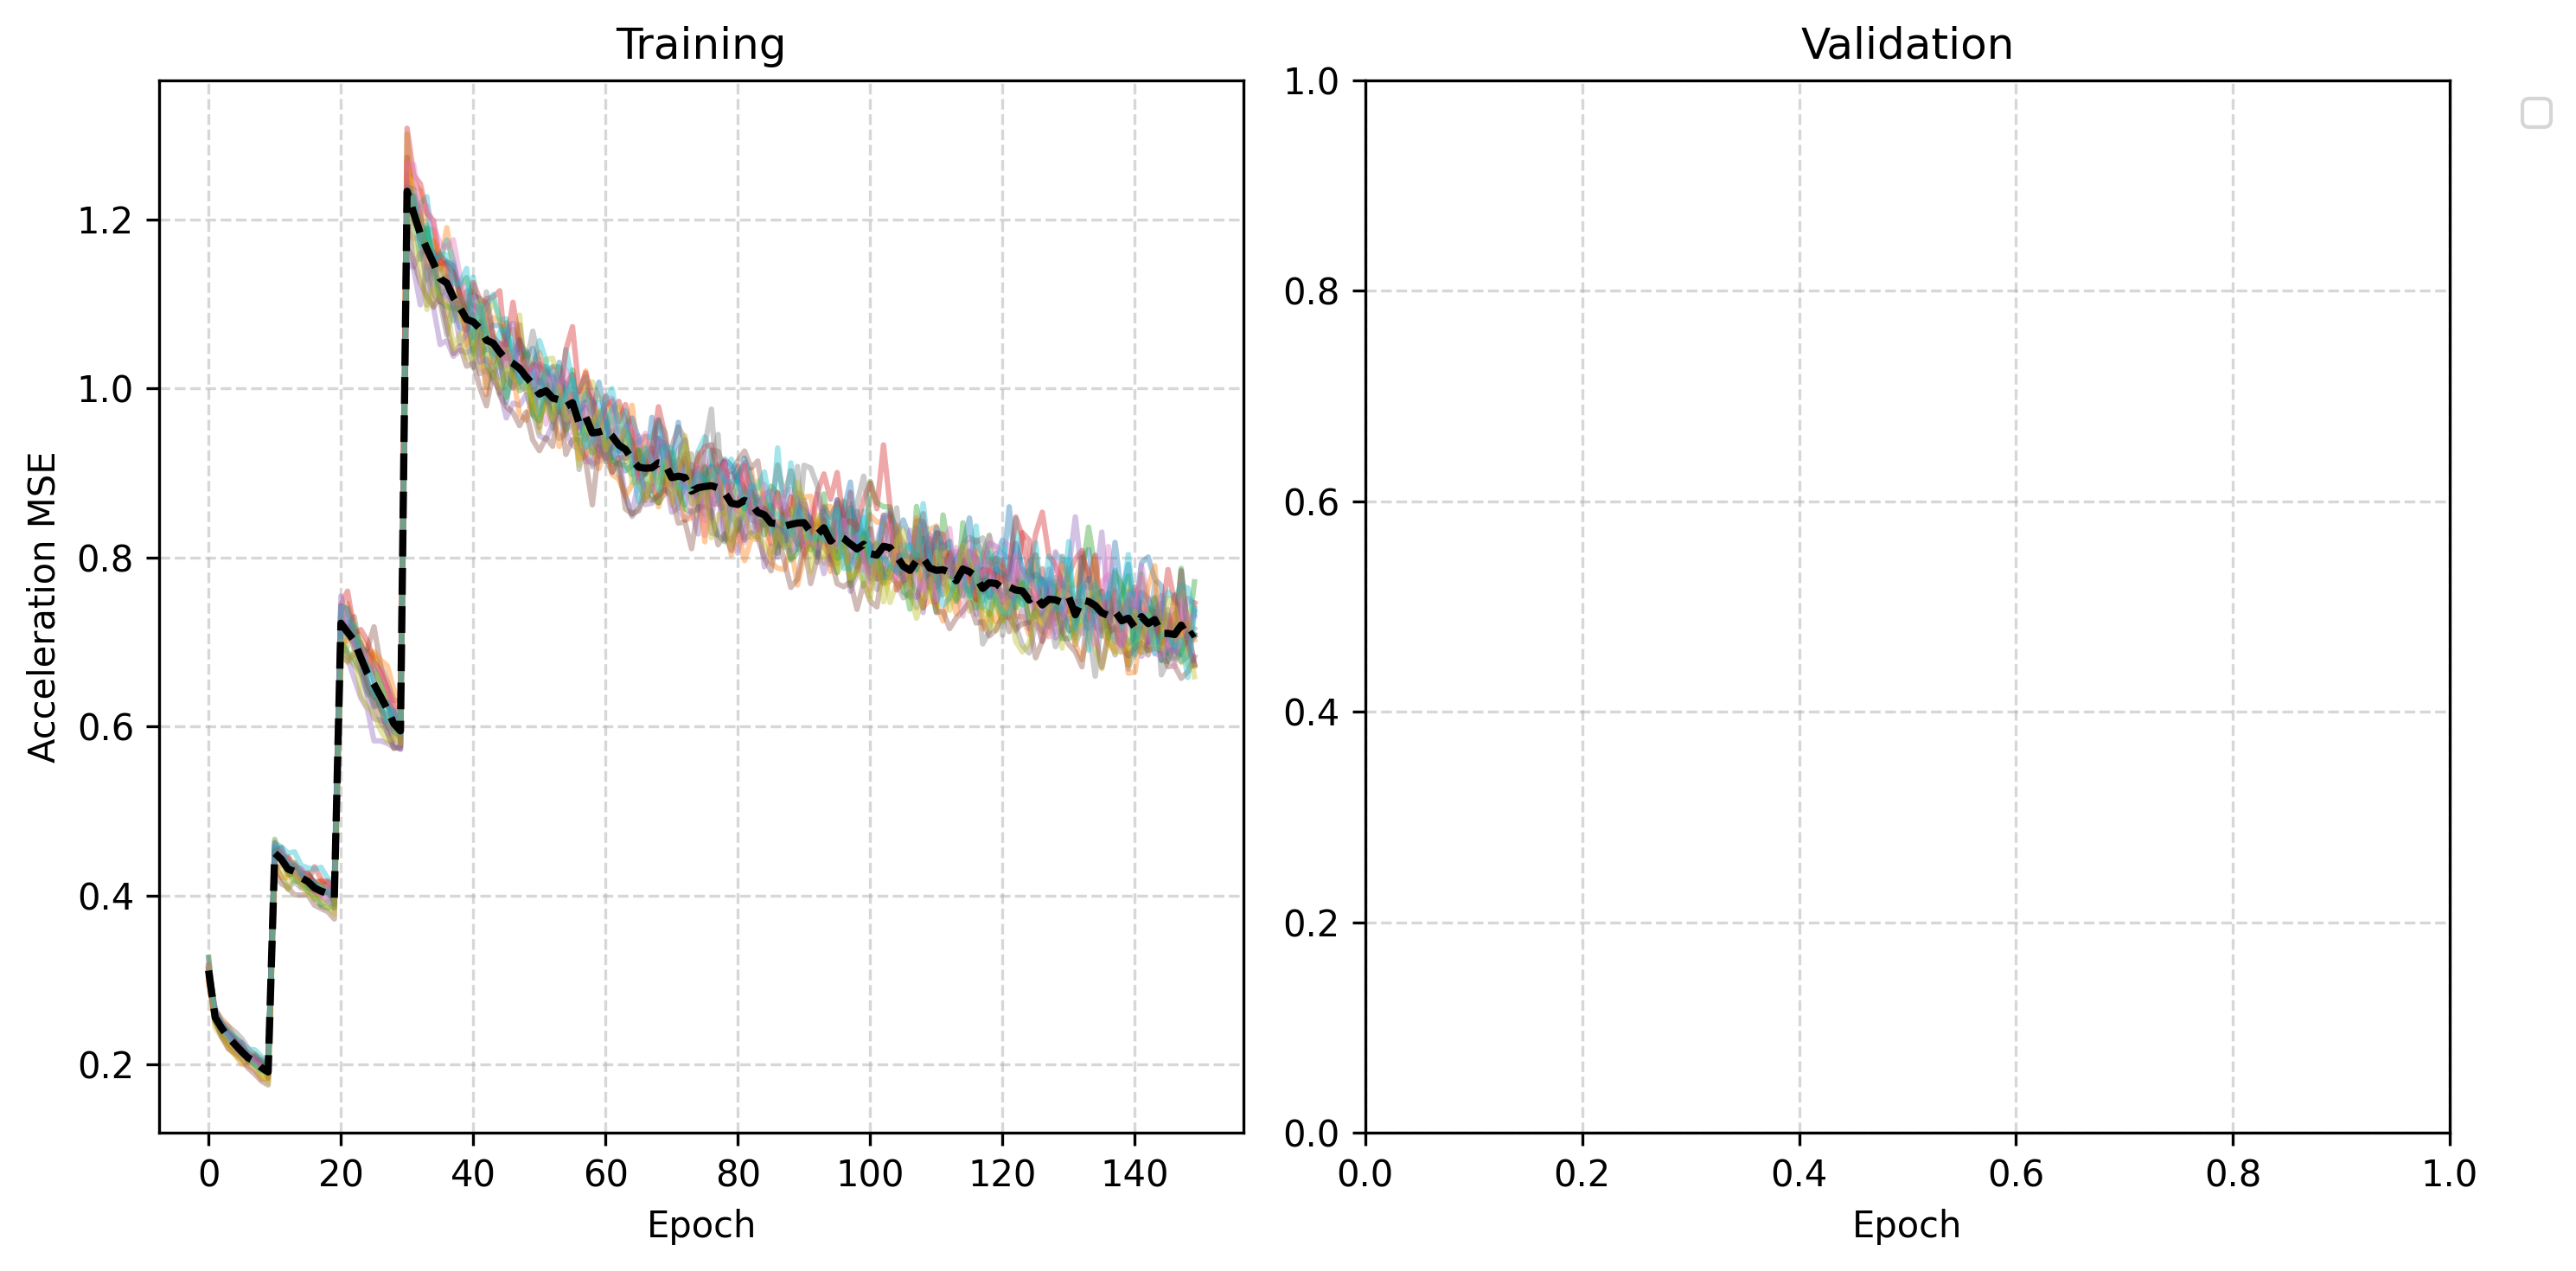

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10.0, 5.0), layout="tight", dpi=300)

validation_interval = 5
epochs_total = 150 
x_axis = np.arange(0, epochs_total, validation_interval)

# Plot individual tries
training_curves = []
validation_curves = []
for i, res in enumerate(results):

    # Plot training loss
    training_loss_curve = res['training_loss']
    training_curves.append(training_loss_curve)
    ax[0].plot(range(epochs_total), training_loss_curve, alpha=0.4, label=f"Try {i+1}")

    # # Plot validation loss
    # validation_loss_curve = res['validation_loss']
    # validation_curves.append(validation_loss_curve)
    # ax[1].plot(range(epochs_total), validation_loss_curve, alpha=0.4, label=f"Try {i+1}")

# Compute mean training loss
training_curves = np.array(training_curves)
mean_training_loss = np.mean(training_curves, axis=0)
ax[0].plot(range(epochs_total), mean_training_loss, linestyle="--", color='black', linewidth=2.0, label="Mean")

# # Compute mean validation loss
# validation_curves = np.array(validation_curves)
# mean_validation_loss = np.mean(validation_curves, axis=0)
# ax[1].plot(range(epochs_total), mean_validation_loss, linestyle="--", color='black', linewidth=2.0, label="Mean")

# Formatting
ax[0].set_title("Training")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Acceleration MSE")
ax[0].grid(True, which="both", ls="--", alpha=0.5)

ax[1].set_title("Validation")
ax[1].set_xlabel("Epoch")
ax[1].grid(True, which="both", ls="--", alpha=0.5)
ax[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

### Plot $R^2$ and rollout Position MSE

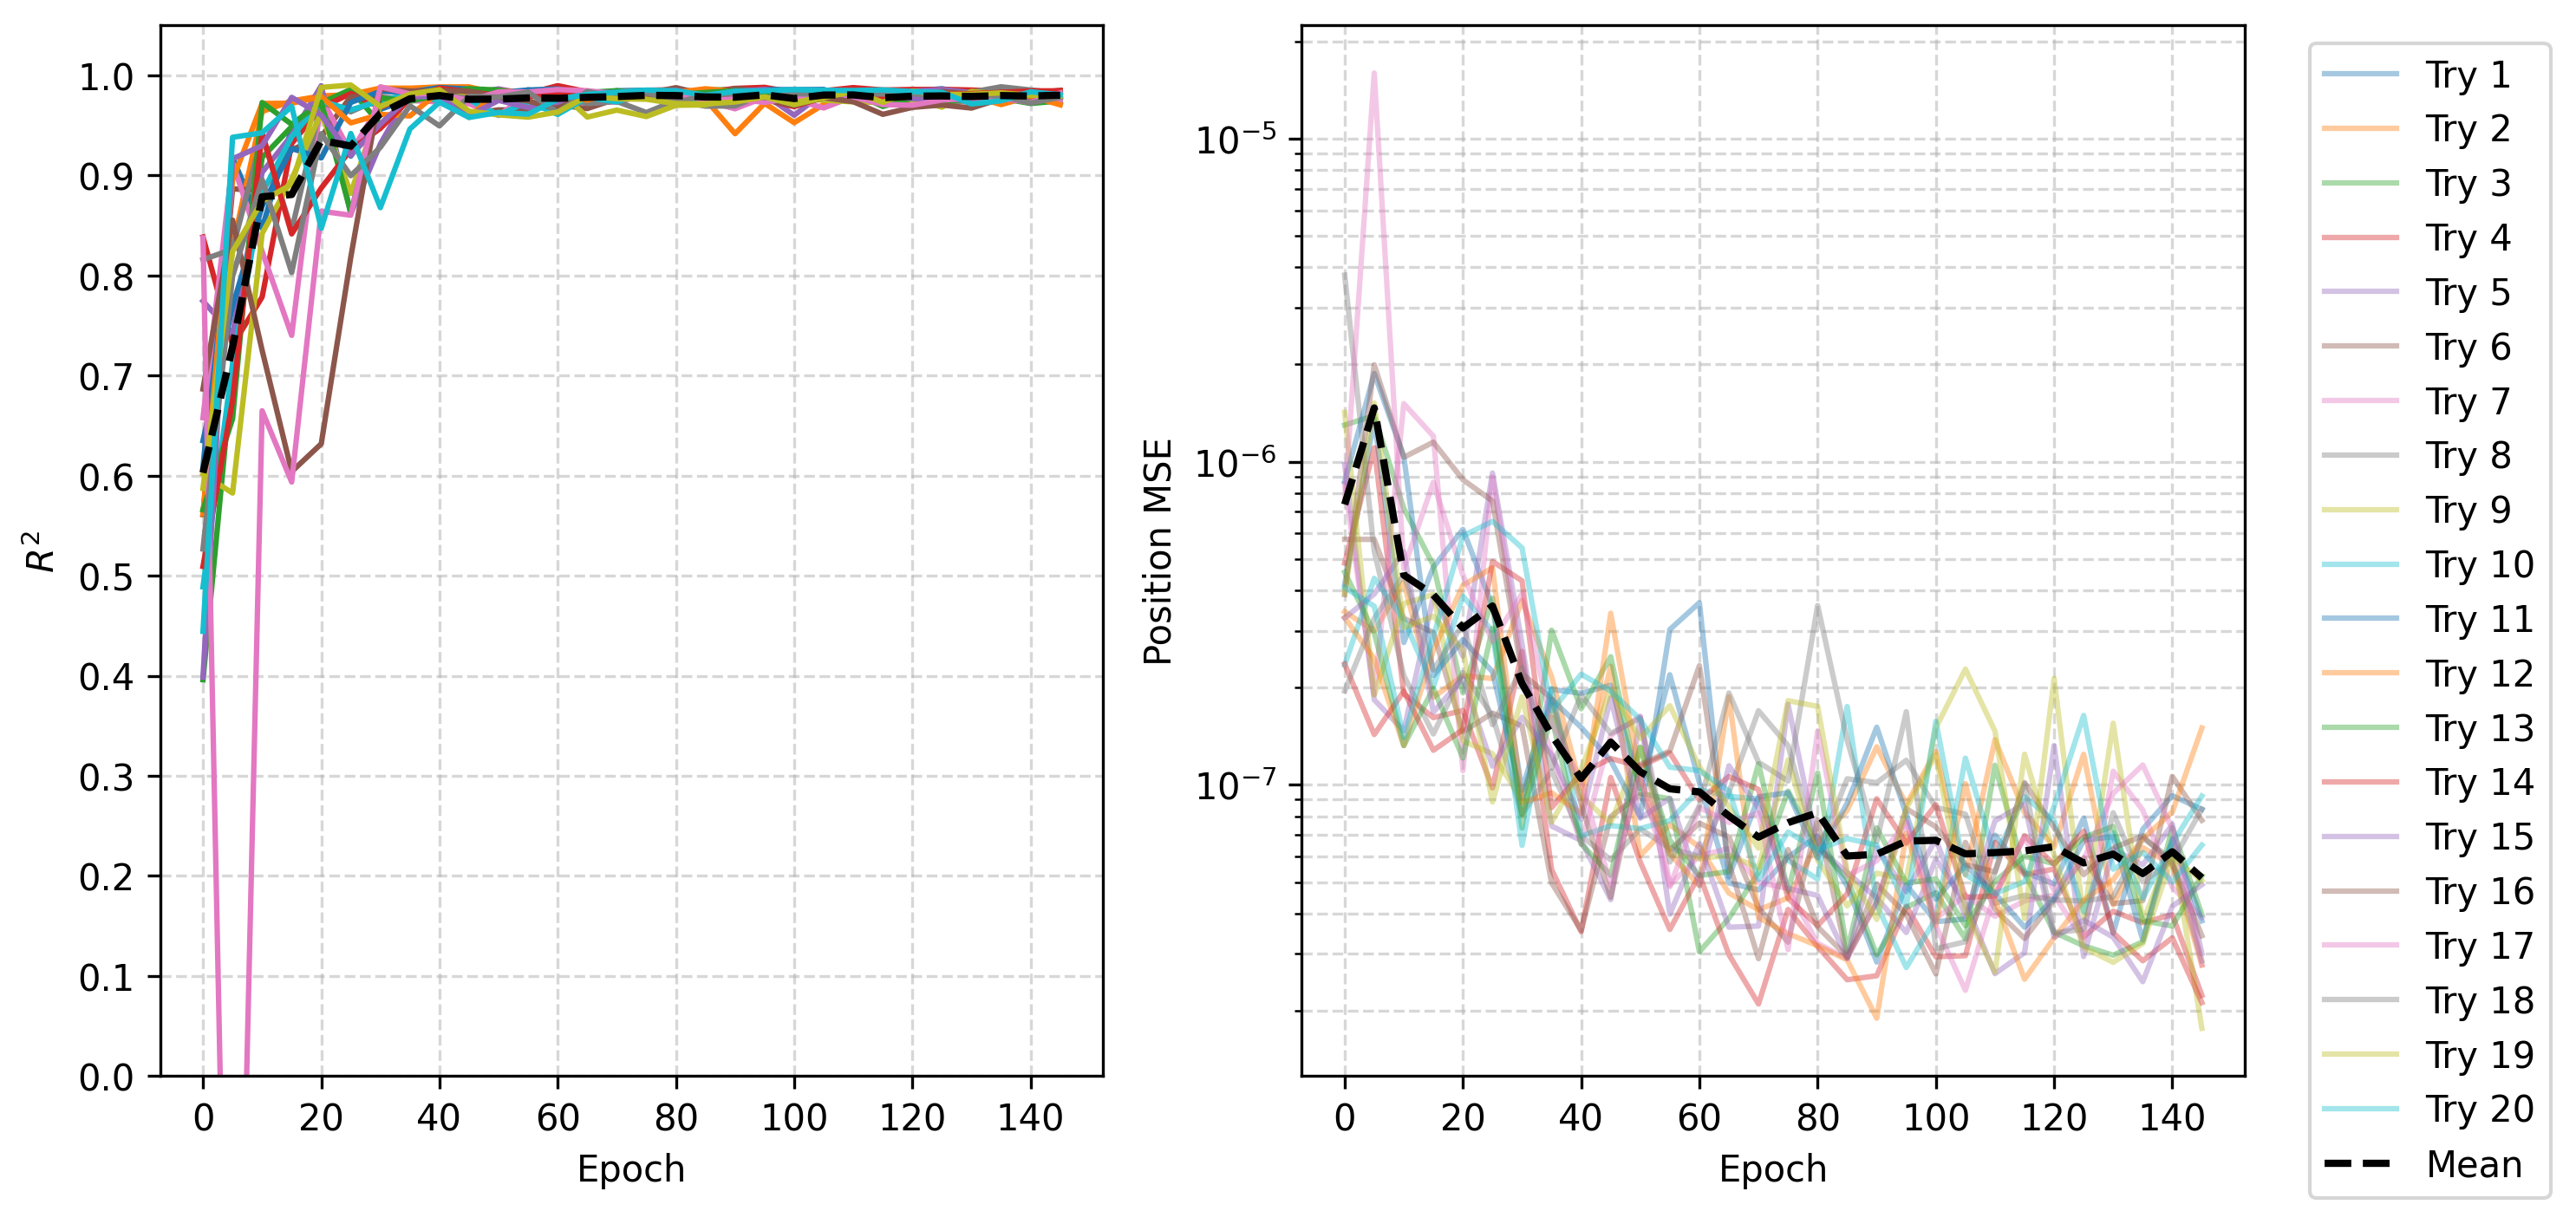

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10.0, 5.0), layout="tight", dpi=300)

validation_interval = 5
epochs_total = 150 
x_axis = np.arange(0, epochs_total, validation_interval)

# Plot individual folds
all_fold_mses = []
all_fold_r2s = []
for i, res in enumerate(results):

    # Plot rollout r2
    r2_curve = res['r2']
    ax[0].plot(x_axis, r2_curve, label=f'Try {i+1}', linewidth=1.5)
    all_fold_r2s.append(r2_curve)

    val_mse_curve = [np.mean(step_mses) for step_mses in res['rollout_mse']] 
    all_fold_mses.append(val_mse_curve)
    ax[1].plot(x_axis, val_mse_curve, label=f'Try {i+1}', alpha=0.4, linewidth=1.5)

# Plot the mean r2 curve
all_fold_r2s = np.array(all_fold_r2s)
mean_r2 = np.mean(all_fold_r2s, axis=0)
ax[0].plot(x_axis, mean_r2, color='black', label='Mean', linewidth=2.0, linestyle="--")

# Plot the mean position MSE curve
all_fold_mses = np.array(all_fold_mses)
mean_mse = np.mean(all_fold_mses, axis=0)
ax[1].plot(x_axis, mean_mse, color='black', label='Mean', linewidth=2.0, linestyle='--')

# Formatting
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("$R^2$")
ax[0].set_yticks(np.linspace(0, 1.0, 11))
ax[0].grid(True, which="both", ls="--", alpha=0.5)
ax[0].set_ylim(0, 1.05)

ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Position MSE")
ax[1].set_yscale('log')
ax[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax[1].grid(True, which="both", ls="--", alpha=0.5)

plt.show()

### Pick the best models according to validation loss and r2

In [16]:
def select_best_models(main_directory: str, top_n: int = 5, eval_interval: int = 5) -> dict:
    """
    Parses cross-validation results and selects the top N models based on R2 
    and the top N models based on 1-step validation loss.
    """
    results_path = os.path.join(main_directory, "monte_carlo_cv_results.pkl")
    
    if not os.path.exists(results_path):
        raise FileNotFoundError(f"Could not find results file at {results_path}")
        
    fold_results = torch.load(results_path)
    print(f"Loaded results for {len(fold_results)} tries.")

    all_checkpoints = []

    # 1. Flatten the results into a list of specific checkpoint metadata
    for try_idx, results in enumerate(fold_results):
        
        # r2 is saved every `eval_interval` epochs (e.g., 0, 5, 10...)
        for r2_idx, r2_val in enumerate(results["r2"]):
            epoch = r2_idx * eval_interval
            
            # Val loss is saved every epoch, so we index it directly by the epoch number
            # val_loss = results["validation_loss"][epoch]
            
            # Handle potential exploding gradients / NaNs
            if math.isnan(r2_val):
                r2_val = float('-inf')
            # if math.isnan(val_loss):
            #     val_loss = float('inf')
                
            ckpt_path = os.path.join(main_directory, f"try_{try_idx + 1}", f"checkpoint_epoch_{epoch}.pt")
            
            # Only consider it if the physical file actually exists
            if os.path.exists(ckpt_path):
                all_checkpoints.append({
                    "try": try_idx+1,
                    "epoch": epoch,
                    "r2": float(r2_val),
                    # "validation_loss": float(val_loss),
                    "checkpoint_path": ckpt_path
                })

    if not all_checkpoints:
        raise ValueError("No valid checkpoints found. Check directory paths.")

    # 2. Sort and select the Best N
    
    # Highest R2 is best
    best_by_r2 = sorted(all_checkpoints, key=lambda x: x["r2"], reverse=True)[:top_n]
    
    # Lowest Validation Loss is best
    # best_by_val_loss = sorted(all_checkpoints, key=lambda x: x["validation_loss"], reverse=False)[:top_n]

    # 3. Format into the requested nested dictionary
    final_selection = {
        "best_based_on_r2": {},
        # "best_based_on_val_loss": {}
    }

    print(f"\n--- Top {top_n} Models by R2 ---")
    for i, model_info in enumerate(best_by_r2):
        final_selection["best_based_on_r2"][f"model_{i}"] = model_info
        # print(f"Rank {i+1} | Try {model_info['try']}, Epoch {model_info['epoch']:>3} | R2: {model_info['r2']:.4f} | Val Loss: {model_info['validation_loss']:.4e}")
        print(f"Rank {i+1} | Try {model_info['try']}, Epoch {model_info['epoch']:>3} | R2: {model_info['r2']:.4f}")

    # print(f"\n--- Top {top_n} Models by Validation Loss ---")
    # for i, model_info in enumerate(best_by_val_loss):
    #     final_selection["best_based_on_val_loss"][f"model_{i}"] = model_info
    #     print(f"Rank {i+1} | Try {model_info['try']}, Epoch {model_info['epoch']:>3} | Val Loss: {model_info['validation_loss']:.4e} | R2: {model_info['r2']:.4f}")

    # 4. Save to JSON for easy consumption by your testing script
    output_path = os.path.join(main_directory, "selected_test_models.json")
    with open(output_path, 'w') as f:
        json.dump(final_selection, f, indent=4)
        
    print(f"\nSelection complete. Saved metadata to {output_path}")
    return final_selection

best_models = select_best_models(main_directory, top_n=15, eval_interval=5)

Loaded results for 20 tries.

--- Top 15 Models by R2 ---
Rank 1 | Try 19, Epoch  25 | R2: 0.9903
Rank 2 | Try 4, Epoch  60 | R2: 0.9897
Rank 3 | Try 5, Epoch  20 | R2: 0.9896
Rank 4 | Try 17, Epoch  30 | R2: 0.9885
Rank 5 | Try 8, Epoch 135 | R2: 0.9885
Rank 6 | Try 2, Epoch  45 | R2: 0.9885
Rank 7 | Try 2, Epoch  40 | R2: 0.9884
Rank 8 | Try 4, Epoch  95 | R2: 0.9880
Rank 9 | Try 19, Epoch  20 | R2: 0.9879
Rank 10 | Try 11, Epoch  40 | R2: 0.9878
Rank 11 | Try 4, Epoch 110 | R2: 0.9877
Rank 12 | Try 6, Epoch  80 | R2: 0.9877
Rank 13 | Try 2, Epoch  30 | R2: 0.9872
Rank 14 | Try 14, Epoch  40 | R2: 0.9872
Rank 15 | Try 2, Epoch  35 | R2: 0.9871

Selection complete. Saved metadata to ./cross_val/node_optimized/MST/selected_test_models.json


### Load the best models

In [17]:
mp_layers = 2
mlp = 3
hidden_size = 128
history = 3
device = "cuda"

init_graph = Data(x=torch.ones((100, history*2)), edge_attr=torch.ones((100, 4)))

for validation_method, models in best_models.items():
    for idx, best_model in models.items():

        checkpoint_path = best_model['checkpoint_path']

        gnn_simulator = VelocityModel(init_graph, hidden_size, mp_layers, mlp, device)
        gnn_simulator.load_checkpoint(checkpoint_path)
        gnn_simulator = freeze_normalizer(gnn_simulator)
        gnn_simulator.to(device)
        best_model['gnn_simulator'] = gnn_simulator

        print(f"Loaded model from try {best_model['try']} epoch {best_model['epoch']}: {checkpoint_path} .")


Successfully loaded and migrated LEGACY checkpoint from ./cross_val/node_optimized/MST/try_19/checkpoint_epoch_25.pt
Loaded model from try 19 epoch 25: ./cross_val/node_optimized/MST/try_19/checkpoint_epoch_25.pt .
Successfully loaded and migrated LEGACY checkpoint from ./cross_val/node_optimized/MST/try_4/checkpoint_epoch_60.pt
Loaded model from try 4 epoch 60: ./cross_val/node_optimized/MST/try_4/checkpoint_epoch_60.pt .
Successfully loaded and migrated LEGACY checkpoint from ./cross_val/node_optimized/MST/try_5/checkpoint_epoch_20.pt
Loaded model from try 5 epoch 20: ./cross_val/node_optimized/MST/try_5/checkpoint_epoch_20.pt .
Successfully loaded and migrated LEGACY checkpoint from ./cross_val/node_optimized/MST/try_17/checkpoint_epoch_30.pt
Loaded model from try 17 epoch 30: ./cross_val/node_optimized/MST/try_17/checkpoint_epoch_30.pt .
Successfully loaded and migrated LEGACY checkpoint from ./cross_val/node_optimized/MST/try_8/checkpoint_epoch_135.pt
Loaded model from try 8 epoch

#### Load all the data at once

In [18]:
registry_path = "./data/data_registry.csv"
df = pd.read_csv(registry_path)
type_df = df[df["data_type"] == f"{dataset_type}"]

all_files = type_df["file_path"].tolist()
max_sim_len = 100

# Dictionary mapping: { "path/to/file.pt" : tensor_data }
master_tensors = {}
for file in tqdm(all_files, desc="Loading & Preparing Data"):
    # Load and process
    sim = torch.load(file, weights_only=False)[:max_sim_len]
    prepared_sim = prepare_traj(sim, calc_angles=False)

    # Store in dict for instant retrieval later
    master_tensors[file] = prepared_sim


Loading & Preparing Data:   0%|          | 0/1998 [00:00<?, ?it/s]

Loading & Preparing Data: 100%|██████████| 1998/1998 [01:54<00:00, 17.38it/s]


### Test the best models on their corresponding test data

In [19]:
# Define some constants
history = 3
test_data_limit = 500
rollout_steps = 50

# Get correct barostat parameters
if dataset_type is DatasetType.NodeOptimized:
    barostat_config = barostat_parameters.node_optimizated
elif dataset_type is DatasetType.StiffOptimized:
    barostat_config = barostat_parameters.stiff_optimized

# Same splits as in training to properly get the test data
train_config = {"count": 200, "p_min": 0.1, "p_max": float("inf")}
val_config = {"count": 200, "p_min": 0.1, "p_max": float("inf")}

results = {}
for validation_method, models in best_models.items():
    results[validation_method] = {}
    for idx, best_model in models.items():

        # In the training, the seed was 42 + try number, zero based
        seed = 42 + best_model['try'] -1

        results[validation_method][idx] = {
            "final_mse": [],
            "mse": [],
            "pred_p": [],
            "gt_p": [],
            "pred_box": [],
            "gt_box": [],
        }

        train_df, val_df, test_df = get_explicit_splits(
            registry_path=registry_path,
            target_data_type=dataset_type,
            train_config=train_config,
            val_config=val_config,
            seed=seed,
        )

        # Get the test data and limit so we don't wait for many hours
        test_data = [master_tensors[path] for path in test_df["file_path"]]
        test_data = test_data[:test_data_limit]

        # Calculate box per-step compression factor
        factors = [(sim[4].box_tensor[0]/sim[3].box_tensor[0]).item() for sim in test_data]
        mean_factor = sum(factors)/len(factors)

        # Get the actual gnn simulator
        gnn_simulator = best_model['gnn_simulator']
        gnn_simulator.eval()

        # Start evaluation loop
        with torch.no_grad():
            for test_sim in tqdm(test_data, desc=f"Try {best_model['try']} epoch {best_model['epoch']}"):

                # This block computes dumping period (N MD steps in 1 dump step)        
                sim_strain = (test_sim[1].box.x - test_sim[-1].box.x) / test_sim[0].box.x
                assumed_rollout_length = int(sim_strain / 1e-5 / 0.01)
                dump_period = int(assumed_rollout_length / len(test_sim)) + 1

                barostat_config_current = deepcopy(barostat_config)
                barostat_config_current["default_skip"] = dump_period

                input_graphs = [g.cpu().detach() for g in test_sim[: history + 1]]

                rollout = get_rollout(
                    input_graphs=input_graphs,
                    gnn_simulator=gnn_simulator,
                    gnn_history=history,
                    num_steps=rollout_steps,
                    barostat_config=barostat_config_current,
                    device="cuda"
                )

                pos_mse = torch.nn.functional.mse_loss(rollout[-1].pos.cpu(), test_sim[len(rollout)-1].pos)
                results[validation_method][idx]["final_mse"].append(pos_mse.item())
                pos_mse = [torch.nn.functional.mse_loss(rollout[i].pos.cpu(), test_sim[i].pos.cpu()).item() for i in range(len(rollout))]
                results[validation_method][idx]["mse"].append(pos_mse)
                
                pred_p = calc_p_ratio_box_tensor(rollout).item()
                results[validation_method][idx]["pred_p"].append(pred_p)
                gt_p = calc_p_ratio_box_tensor(test_sim[:len(rollout)]).item()
                results[validation_method][idx]["gt_p"].append(gt_p)

                pred_box = [g.box_tensor.cpu().detach() for g in rollout]
                results[validation_method][idx]["pred_box"].append(pred_box)
                gt_box = [g.box_tensor.cpu().detach() for g in test_sim[: len(rollout)]]
                results[validation_method][idx]["gt_box"].append(gt_box)


Try 2 epoch 35: 100%|██████████| 500/500 [00:52<00:00,  9.44it/s]


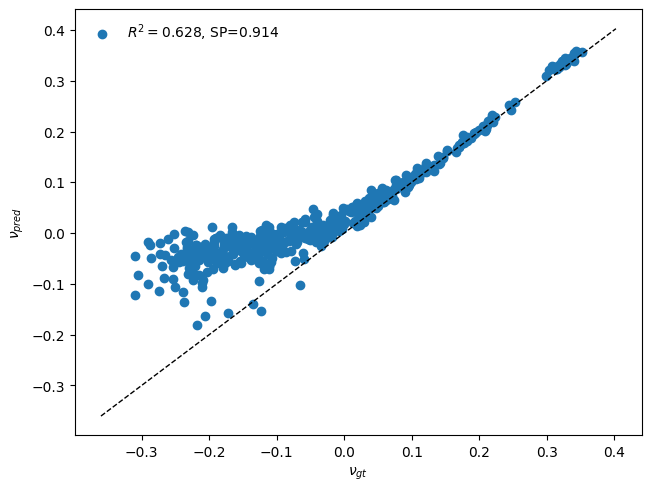

In [22]:
fig, ax = plt.subplots(1, 1, layout="constrained")

specific_results = results['best_based_on_r2']['model_14']

line = (min(specific_results["gt_p"]) - 0.05, max(specific_results["gt_p"]) + 0.05)
ax.plot(line, line, color="black", linewidth=1, linestyle='--')

# for model_name, results in specific_results.items():

r2 = r2_score(specific_results['gt_p'], specific_results['pred_p'])
res = spearmanr(specific_results["gt_p"], specific_results["pred_p"])
sp = res.statistic
    
label_text = f"$R^2={r2:.3f}$, SP={sp:.3f}"
ax.scatter(specific_results["gt_p"], specific_results["pred_p"], label=label_text)
    
ax.legend(frameon=False, loc='best')
ax.set_xlabel(r"$\nu_{gt}$")
ax.set_ylabel(r"$\nu_{pred}$")


plt.show()

Skipping best_based_on_val_loss - data not found.
Saved Generalization Dashboard to ./cross_val/node_optimized/OST/plots/generalization_gap_dashboard.png


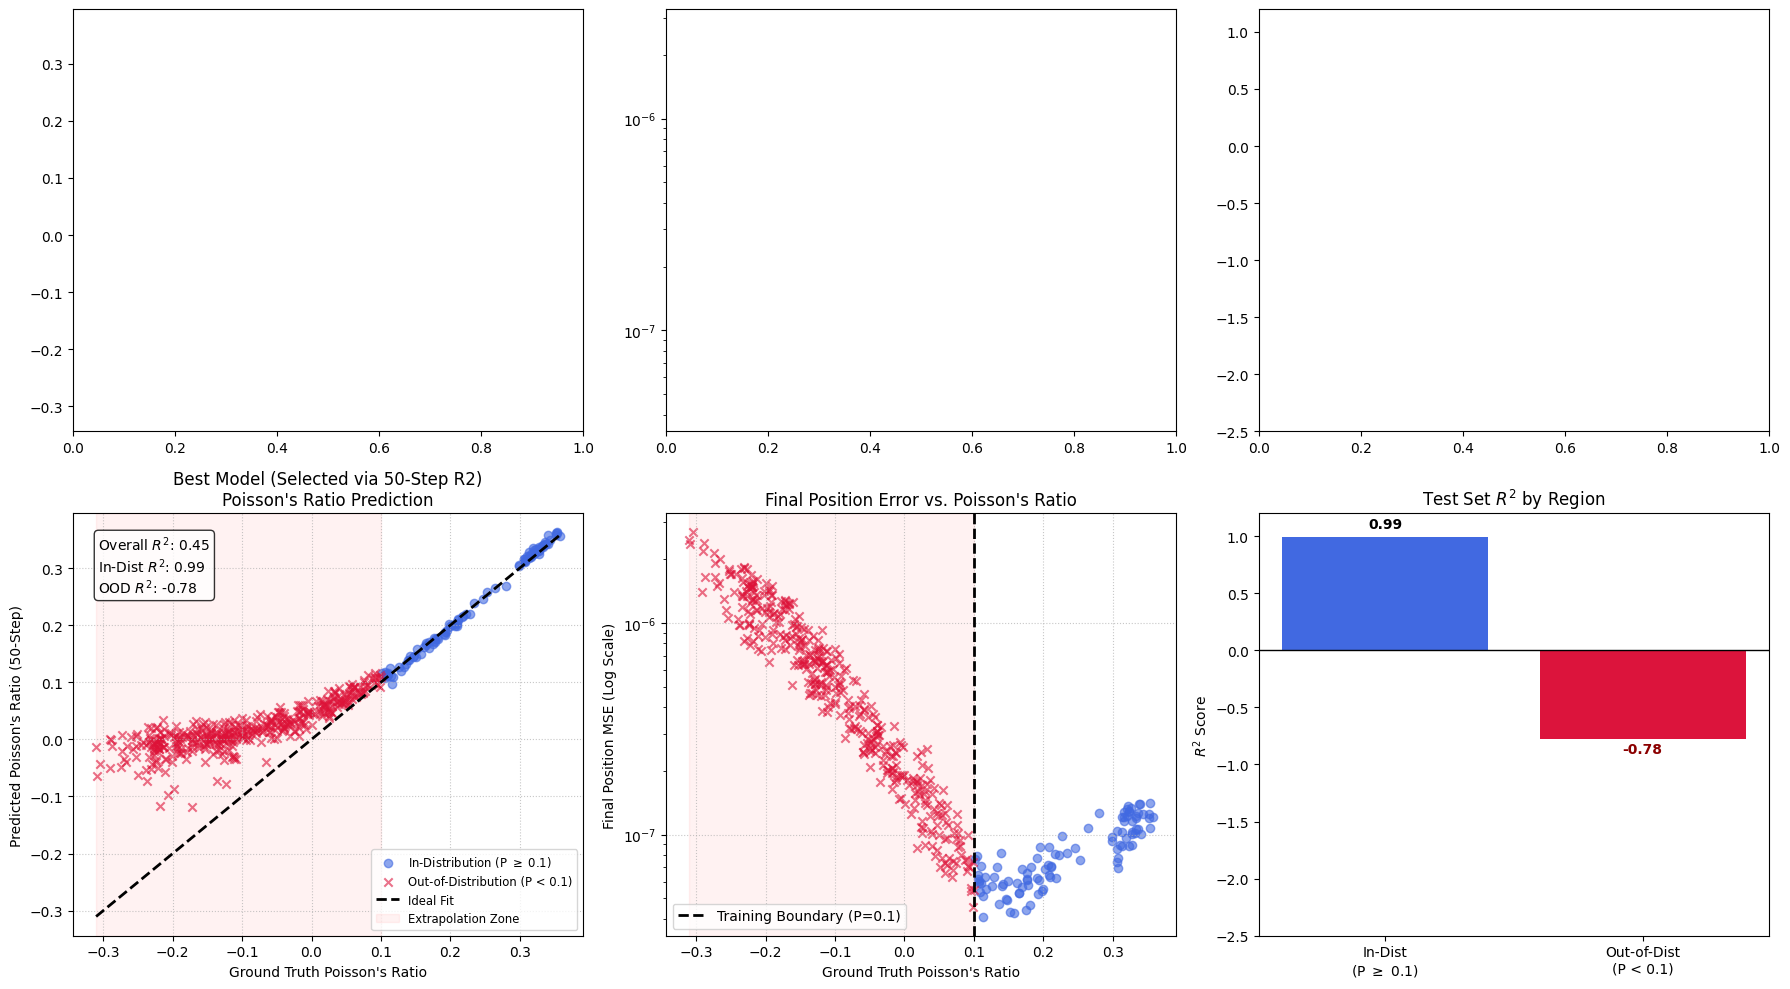

In [ ]:
def plot_generalization_dashboard(results: dict, save_dir: str = "./plots"):
    os.makedirs(save_dir, exist_ok=True)
    
    # We will plot the Rank 1 ("model_0") for both selection criteria
    methods = ["best_based_on_val_loss", "best_based_on_r2"]
    method_titles = ["Best Model (Selected via 1-Step Val Loss)", "Best Model (Selected via 50-Step R2)"]
    
    # sharey='col' ensures the middle plots (MSE) have identical y-scales, 
    # and also links parity plots and R2 bar charts vertically for easy comparison.
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10), sharey='col')
    fig.subplots_adjust(hspace=0.4, wspace=0.3)
    
    for row, (method, title) in enumerate(zip(methods, method_titles)):
        # Extract the top model's data
        if method not in results or "model_0" not in results[method]:
            print(f"Skipping {method} - data not found.")
            continue
            
        model_data = results[method]["model_0"]
        
        gt_p = np.array(model_data["gt_p"])
        pred_p = np.array(model_data["pred_p"])
        mse = np.array(model_data["final_mse"])
        
        # Create masks for In-Distribution (>=0.1) and Out-Of-Distribution (<0.1)
        in_dist_mask = gt_p >= 0.1
        ood_mask = gt_p < 0.1
        
        # Safely calculate R2 (fallback to -1.0 if totally exploded to avoid breaking chart bounds)
        # try:
        overall_r2 = r2_score(gt_p, pred_p)
        # except:
        #     overall_r2 = -10.0
            
        # try:
        in_dist_r2 = r2_score(gt_p[in_dist_mask], pred_p[in_dist_mask])
        # except:
        #     in_dist_r2 = -10.0
            
        # try:
        ood_r2 = r2_score(gt_p[ood_mask], pred_p[ood_mask])
        # except:
        #     ood_r2 = -1.0

        # ==========================================
        # Panel 1: Parity Plot (Predicted vs True P)
        # ==========================================
        ax1 = axes[row, 0]
        
        # Plot data points
        ax1.scatter(gt_p[in_dist_mask], pred_p[in_dist_mask], color='royalblue', alpha=0.6, label='In-Distribution (P $\\geq$ 0.1)')
        ax1.scatter(gt_p[ood_mask], pred_p[ood_mask], color='crimson', alpha=0.6, marker='x', label='Out-of-Distribution (P < 0.1)')
        
        # Ideal y=x line
        min_val, max_val = min(gt_p), max(gt_p)
        ax1.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Ideal Fit')
        
        # Shaded Extrapolation Zone
        ax1.axvspan(min_val, 0.1, color='red', alpha=0.05, label='Extrapolation Zone')
        
        # Add R2 values directly onto the plot
        r2_text = f"Overall $R^2$: {overall_r2:.2f}\nIn-Dist $R^2$: {in_dist_r2:.2f}\nOOD $R^2$: {ood_r2:.2f}"
        ax1.text(0.05, 0.95, r2_text, transform=ax1.transAxes, fontsize=10,
                 verticalalignment='top', bbox={"boxstyle": 'round', "facecolor": 'white', "alpha": 0.8})
        
        ax1.set_title(f"{title}\nPoisson's Ratio Prediction")
        ax1.set_xlabel("Ground Truth Poisson's Ratio")
        ax1.set_ylabel("Predicted Poisson's Ratio (50-Step)")
        ax1.legend(loc='lower right', fontsize='small')
        ax1.grid(True, linestyle=':', alpha=0.7)

        # ==========================================
        # Panel 2: Position Error Avalanche
        # ==========================================
        ax2 = axes[row, 1]
        
        ax2.scatter(gt_p[in_dist_mask], mse[in_dist_mask], color='royalblue', alpha=0.6)
        ax2.scatter(gt_p[ood_mask], mse[ood_mask], color='crimson', alpha=0.6, marker='x')
        
        ax2.axvline(x=0.1, color='black', linestyle='--', lw=2, label='Training Boundary (P=0.1)')
        ax2.axvspan(min_val, 0.1, color='red', alpha=0.05)
        
        ax2.set_title("Final Position Error vs. Poisson's Ratio")
        ax2.set_xlabel("Ground Truth Poisson's Ratio")
        ax2.set_ylabel("Final Position MSE (Log Scale)")
        ax2.set_yscale('log')
        ax2.legend(loc='best')
        ax2.grid(True, linestyle=':', alpha=0.7)

        # ==========================================
        # Panel 3: Segmented R-Squared Reality Check
        # ==========================================
        ax3 = axes[row, 2]
            
        # Cap out-of-distribution R2 for plotting purposes if it drops to -5000
        plot_ood_r2 = max(ood_r2, -2.0) 
            
        ax3.bar(['In-Dist\n(P $\\geq$ 0.1)', 'Out-of-Dist\n(P < 0.1)'], [in_dist_r2, plot_ood_r2], color=['royalblue', 'crimson'])
        
        ax3.set_title("Test Set $R^2$ by Region")
        ax3.set_ylabel("$R^2$ Score")
        ax3.axhline(0, color='black', lw=1) # Zero line
        ax3.set_ylim([-2.5, 1.2]) # Fixed Y-limits for easy comparison
        
        # Add text labels on top of bars
        ax3.text(0, in_dist_r2 + 0.05, f"{in_dist_r2:.2f}", ha='center', va='bottom', fontweight='bold')
        label_y = plot_ood_r2 + 0.05 if plot_ood_r2 >= 0 else plot_ood_r2 - 0.15
        ax3.text(1, label_y, f"{ood_r2:.2f}", ha='center', va='bottom', fontweight='bold', color='darkred')

    plt.tight_layout()
    save_path = os.path.join(save_dir, "generalization_gap_dashboard.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved Generalization Dashboard to {save_path}")
    plt.show()


plot_generalization_dashboard(results, save_dir="./cross_val/node_optimized/OST/plots")

Saved Correlation Dashboard to ./cross_val/node_optimized/MST/plots/validation_vs_test_correlation.png


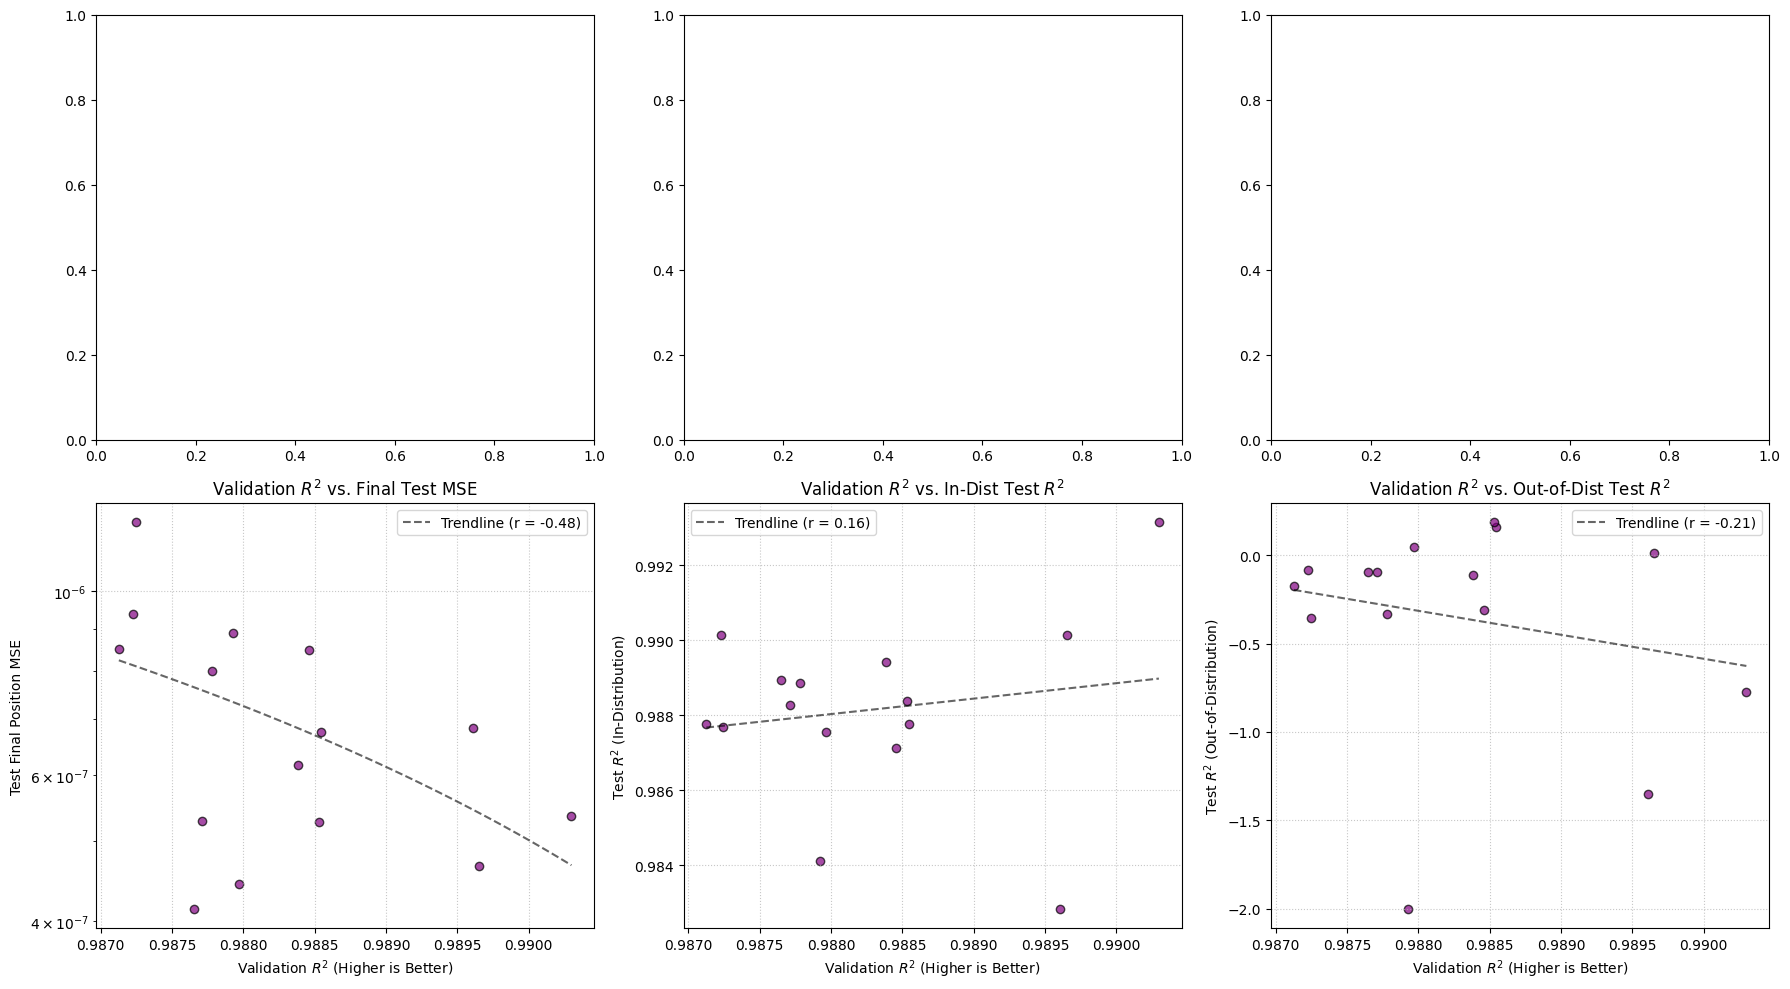

In [ ]:
# def plot_validation_vs_test_correlation(test_results: dict, best_models_metadata: dict, save_dir: str = "./plots"):
#     """
#     Plots Validation Metrics vs Test Metrics to analyze generalization correlation.
#     Expects 'test_results' (from the testing script) and 'best_models_metadata' (from model_selector.py).
#     """
#     os.makedirs(save_dir, exist_ok=True)
    
#     val_losses = []
#     val_r2s = []
    
#     test_mses = []
#     test_r2s_indist = []
#     test_r2s_ood = []
    
#     # Aggregate data across all selected models
#     for method in test_results.keys():
#         for idx in test_results[method].keys():
#             # Get validation metadata
#             val_loss = best_models_metadata[method][idx]["validation_loss"]
#             val_r2 = best_models_metadata[method][idx]["r2"]
            
#             # Get test arrays
#             gt_p = np.array(test_results[method][idx]["gt_p"])
#             pred_p = np.array(test_results[method][idx]["pred_p"])
#             mse = np.array(test_results[method][idx]["final_mse"])
            
#             # Sub-divide by distribution
#             in_dist_mask = gt_p >= 0.1
#             ood_mask = gt_p < 0.1
            
#             # Calculate test metrics
#             test_mse_mean = np.mean(mse)
            
#             try:
#                 t_r2_in = r2_score(gt_p[in_dist_mask], pred_p[in_dist_mask])
#             except:
#                 t_r2_in = -2.0
                
#             try:
#                 t_r2_ood = r2_score(gt_p[ood_mask], pred_p[ood_mask])
#             except:
#                 t_r2_ood = -2.0
                
#             # Filter out models that completely exploded to infinity during validation
#             # (so they don't break the matplotlib scale)
#             if val_r2 > -5.0 and t_r2_ood > -5.0: 
#                 val_losses.append(val_loss)
#                 val_r2s.append(val_r2)
#                 test_mses.append(test_mse_mean)
#                 test_r2s_indist.append(t_r2_in)
#                 test_r2s_ood.append(t_r2_ood)
                
#     # Convert to numpy arrays for plotting and polyfit
#     val_losses = np.array(val_losses)
#     val_r2s = np.array(val_r2s)
#     test_mses = np.array(test_mses)
#     test_r2s_indist = np.array(test_r2s_indist)
#     test_r2s_ood = np.array(test_r2s_ood)
    
#     fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
#     def add_trendline_and_corr(ax, x, y, title, xlabel, ylabel, invert_xaxis=False):
#         ax.scatter(x, y, color='purple', alpha=0.7, edgecolors='black')
#         ax.set_title(title)
#         ax.set_xlabel(xlabel)
#         ax.set_ylabel(ylabel)
#         ax.grid(True, linestyle=':', alpha=0.7)
        
#         if invert_xaxis:
#             ax.invert_xaxis() # Lower validation loss is better, so flip axis to show "better" on the right
            
#         if len(x) > 1:
#             # Calculate Pearson correlation coefficient
#             r = np.corrcoef(x, y)[0, 1]
#             # Add trendline
#             z = np.polyfit(x, y, 1)
#             p = np.poly1d(z)
            
#             # Plot trendline across the range of x
#             x_seq = np.linspace(min(x), max(x), 100)
#             ax.plot(x_seq, p(x_seq), "k--", alpha=0.6, label=f"Trendline (r = {r:.2f})")
#             ax.legend(loc="best")

#     # Panel 1: Validation Loss vs Test Position MSE
#     add_trendline_and_corr(
#         axes[0], val_losses, test_mses, 
#         title="1-Step Val Loss vs. Final Test MSE", 
#         xlabel="Validation Loss (Lower is Better)", 
#         ylabel="Test Final Position MSE",
#         invert_xaxis=True 
#     )
#     axes[0].set_yscale('log')
    
#     # Panel 2: Validation R2 vs IN-DISTRIBUTION Test R2
#     add_trendline_and_corr(
#         axes[1], val_r2s, test_r2s_indist, 
#         title="Validation $R^2$ vs. In-Dist Test $R^2$", 
#         xlabel="Validation $R^2$ (Higher is Better)", 
#         ylabel="Test $R^2$ (In-Distribution)"
#     )
    
#     # Panel 3: Validation R2 vs OUT-OF-DISTRIBUTION Test R2
#     add_trendline_and_corr(
#         axes[2], val_r2s, test_r2s_ood, 
#         title="Validation $R^2$ vs. Out-of-Dist Test $R^2$", 
#         xlabel="Validation $R^2$ (Higher is Better)", 
#         ylabel="Test $R^2$ (Out-of-Distribution)"
#     )

#     plt.tight_layout()
#     save_path = os.path.join(save_dir, "validation_vs_test_correlation.png")
#     plt.savefig(save_path, dpi=300, bbox_inches='tight')
#     print(f"Saved Correlation Dashboard to {save_path}")
#     plt.show()


def plot_validation_vs_test_correlation(test_results: dict, best_models_metadata: dict, save_dir: str = "./plots"):
    """
    Plots Validation Metrics vs Test Metrics to analyze generalization correlation.
    Expects 'test_results' (from the testing script) and 'best_models_metadata' (from model_selector.py).
    """
    os.makedirs(save_dir, exist_ok=True)
    
    val_losses = []
    val_r2s = []
    
    test_mses = []
    test_r2s_indist = []
    test_r2s_ood = []
    
    # Aggregate data across all selected models
    for method in test_results:
        for idx in test_results[method]:
            # Get validation metadata
            # val_loss = best_models_metadata[method][idx]["validation_loss"]
            val_r2 = best_models_metadata[method][idx]["r2"]
            
            # Get test arrays
            gt_p = np.array(test_results[method][idx]["gt_p"])
            pred_p = np.array(test_results[method][idx]["pred_p"])
            mse = np.array(test_results[method][idx]["final_mse"])
            
            # Sub-divide by distribution
            in_dist_mask = gt_p >= 0.1
            ood_mask = gt_p < 0.1
            
            # Calculate test metrics
            test_mse_mean = np.mean(mse)
            
            try:
                t_r2_in = r2_score(gt_p[in_dist_mask], pred_p[in_dist_mask])
            except:  # noqa: E722
                t_r2_in = -2.0
                
            try:
                t_r2_ood = r2_score(gt_p[ood_mask], pred_p[ood_mask])
            except:  # noqa: E722
                t_r2_ood = -2.0
                
            # Filter out models that completely exploded to infinity during validation
            # (so they don't break the matplotlib scale)
            if val_r2 > -5.0 and t_r2_ood > -5.0: 
                # val_losses.append(val_loss)
                val_r2s.append(val_r2)
                test_mses.append(test_mse_mean)
                test_r2s_indist.append(t_r2_in)
                test_r2s_ood.append(t_r2_ood)
                
    # Convert to numpy arrays for plotting and polyfit
    val_losses = np.array(val_losses)
    val_r2s = np.array(val_r2s)
    test_mses = np.array(test_mses)
    test_r2s_indist = np.array(test_r2s_indist)
    test_r2s_ood = np.array(test_r2s_ood)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.subplots_adjust(hspace=0.3, wspace=0.2)
    
    def add_trendline_and_corr(ax, x, y, title, xlabel, ylabel, invert_xaxis=False):
        ax.scatter(x, y, color='purple', alpha=0.7, edgecolors='black')
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.grid(True, linestyle=':', alpha=0.7)
        
        if invert_xaxis:
            ax.invert_xaxis() # Lower validation loss is better, so flip axis to show "better" on the right
            
        if len(x) > 1:
            # Calculate Pearson correlation coefficient
            r = np.corrcoef(x, y)[0, 1]
            # Add trendline
            z = np.polyfit(x, y, 1)
            p = np.poly1d(z)
            
            # Plot trendline across the range of x
            x_seq = np.linspace(min(x), max(x), 100)
            ax.plot(x_seq, p(x_seq), "k--", alpha=0.6, label=f"Trendline (r = {r:.2f})")
            ax.legend(loc="best")

    # ==========================================
    # Row 1: Validation Loss vs All Test Metrics
    # ==========================================
    # add_trendline_and_corr(
    #     axes[0, 0], val_losses, test_mses, 
    #     title="1-Step Val Loss vs. Final Test MSE", 
    #     xlabel="Validation Loss (Lower is Better)", 
    #     ylabel="Test Final Position MSE",
    #     invert_xaxis=True 
    # )
    # axes[0, 0].set_yscale('log')
    
    # add_trendline_and_corr(
    #     axes[0, 1], val_losses, test_r2s_indist, 
    #     title="1-Step Val Loss vs. In-Dist Test $R^2$", 
    #     xlabel="Validation Loss (Lower is Better)", 
    #     ylabel="Test $R^2$ (In-Distribution)",
    #     invert_xaxis=True
    # )
    
    # add_trendline_and_corr(
    #     axes[0, 2], val_losses, test_r2s_ood, 
    #     title="1-Step Val Loss vs. Out-of-Dist Test $R^2$", 
    #     xlabel="Validation Loss (Lower is Better)", 
    #     ylabel="Test $R^2$ (Out-of-Distribution)",
    #     invert_xaxis=True
    # )

    # ==========================================
    # Row 2: Validation R2 vs All Test Metrics
    # ==========================================
    add_trendline_and_corr(
        axes[1, 0], val_r2s, test_mses, 
        title="Validation $R^2$ vs. Final Test MSE", 
        xlabel="Validation $R^2$ (Higher is Better)", 
        ylabel="Test Final Position MSE"
    )
    axes[1, 0].set_yscale('log')
    
    add_trendline_and_corr(
        axes[1, 1], val_r2s, test_r2s_indist, 
        title="Validation $R^2$ vs. In-Dist Test $R^2$", 
        xlabel="Validation $R^2$ (Higher is Better)", 
        ylabel="Test $R^2$ (In-Distribution)"
    )
    
    add_trendline_and_corr(
        axes[1, 2], val_r2s, test_r2s_ood, 
        title="Validation $R^2$ vs. Out-of-Dist Test $R^2$", 
        xlabel="Validation $R^2$ (Higher is Better)", 
        ylabel="Test $R^2$ (Out-of-Distribution)"
    )

    plt.tight_layout()
    save_path = os.path.join(save_dir, "validation_vs_test_correlation.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved Correlation Dashboard to {save_path}")
    plt.show()

plot_validation_vs_test_correlation(results, best_models, save_dir="./cross_val/node_optimized/MST/plots")

### A different way of picking data

In [ ]:
import logging
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm


def get_cv_and_test_pools(
    registry_path: str,
    target_data_type: str,
    cv_buckets: list,
    test_buckets: list,
    seed: int = 42,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Safely extracts a Holdout Test Pool, then extracts a Cross-Validation Pool 
    from the REMAINING data to guarantee absolutely zero data leakage.
    """
    df = pd.read_csv(registry_path)
    type_df = df[df["data_type"] == str(target_data_type)].copy()

    if type_df.empty:
        raise ValueError(f"No data found for data_type: {target_data_type}")

    def sample_buckets(pool_df, buckets, pool_name):
        sampled_dfs = []
        for i, bucket in enumerate(buckets):
            p_min = bucket.get("min", float("-inf"))
            p_max = bucket.get("max", float("inf"))
            req_count = bucket["count"]

            bucket_df = pool_df[(pool_df["poisson_ratio"] >= p_min) & (pool_df["poisson_ratio"] < p_max)].copy()
            
            available = len(bucket_df)
            if available == 0:
                logging.warning(f"{pool_name} Bucket {i} ({p_min} <= P < {p_max}) is empty.")  # noqa: LOG015
                continue

            take_count = min(req_count, available)
            sampled = bucket_df.sample(n=take_count, random_state=seed)
            sampled["bucket_id"] = i
            sampled_dfs.append(sampled)
            
        if not sampled_dfs:
            raise ValueError(f"No data sampled for {pool_name}.")
            
        return pd.concat(sampled_dfs).sample(frac=1, random_state=seed).reset_index(drop=True)

    # 1. Sample the Test pool first
    test_df = sample_buckets(type_df, test_buckets, "Test")
    
    # 2. Remove Test data from available pool
    remaining_df = type_df[~type_df["file_path"].isin(test_df["file_path"])]
    
    # 3. Sample CV pool from the leftovers
    cv_df = sample_buckets(remaining_df, cv_buckets, "CV")

    return cv_df, test_df


def plot_fold_distributions(train_df, val_df, test_df, fold_num, save_dir):
    """Generates a 3-panel histogram visualizing the exact distributions used in the fold."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
    
    bins = np.linspace(-0.5, 0.5, 20) # Adjust based on your actual physical P limits
    
    # Plot Train
    axes[0].hist(train_df['poisson_ratio'], bins=bins, color='skyblue', edgecolor='black')
    axes[0].set_title(f"Train Set (n={len(train_df)})")
    axes[0].set_xlabel("Poisson's Ratio")
    axes[0].set_ylabel("Count")
    
    # Plot Validation
    axes[1].hist(val_df['poisson_ratio'], bins=bins, color='lightgreen', edgecolor='black')
    axes[1].set_title(f"Validation Set (n={len(val_df)})")
    axes[1].set_xlabel("Poisson's Ratio")
    
    # Plot Test
    axes[2].hist(test_df['poisson_ratio'], bins=bins, color='salmon', edgecolor='black')
    axes[2].set_title(f"Test Set (n={len(test_df)})")
    axes[2].set_xlabel("Poisson's Ratio")
    
    fig.suptitle(f"Data Distribution for Fold {fold_num}", fontsize=14)
    plt.tight_layout()

    plot_path = os.path.join(save_dir, f"fold_{fold_num}_distributions.png")
    plt.savefig(plot_path, dpi=200)
    plt.close()
    logging.info(f"Saved distribution histogram to {plot_path}")  # noqa: LOG015


cv_buckets = [
    {"max": 0.1, "count": 500},  
    {"min": 0.1, "max": 0.2, "count": 500},  
    {"min": 0.2, "count": 300},  
]

test_buckets = [
    {"max": 0.1, "count": 70},  
    {"min": 0.1, "max": 0.2, "count": 70},  
    {"min": 0.2, "count": 70},  
]

cv_pool, test_pool = get_cv_and_test_pools(
    registry_path="./data/data_registry.csv",
    target_data_type=DatasetType.NodeOptimized,
    cv_buckets=cv_buckets,
    test_buckets=test_buckets,
    seed=42
)


In [ ]:
# Optional: Load ALL data into memory ONCE based on these DataFrames
# master_dataset = load_your_tensors_here(cv_df['file_path'].tolist() + test_df['file_path'].tolist())

k_folds = 3
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# ==========================================
# EXPERIMENT CONFIGURATION
# Adjust these variables to test your hypothesis!
# ==========================================
# TRAIN_P_MIN = 0.1
TRAIN_P_MIN = float('-inf')
TRAIN_P_MAX = float('inf')

# VAL_P_MIN = 0.1  # Set this to -inf to validate on full range, or 0.1 to validate on high P
VAL_P_MIN = float('-inf')  
VAL_P_MAX = float('inf')

for res, (train_idx, val_idx) in enumerate(skf.split(cv_pool, cv_pool["bucket_id"])):
    print(f"\n{'='*40}\nStarting Fold {res + 1}/{k_folds}\n{'='*40}")
    
    # 1. Get the mathematically split raw data for this fold
    raw_train_df = cv_pool.iloc[train_idx]
    raw_val_df = cv_pool.iloc[val_idx]

    # 2. DYNAMICALLY FILTER THE DISTRIBUTIONS
    fold_train_df = raw_train_df[
        (raw_train_df['poisson_ratio'] >= TRAIN_P_MIN) & 
        (raw_train_df['poisson_ratio'] < TRAIN_P_MAX)
    ]
    
    fold_val_df = raw_val_df[
        (raw_val_df['poisson_ratio'] >= VAL_P_MIN) & 
        (raw_val_df['poisson_ratio'] < VAL_P_MAX)
    ]
    
    # 3. Visualize the distributions before doing any training
    main_directory = "./data_splits"
    os.makedirs(main_directory, exist_ok=True)
    fold_save_dir = os.path.join(main_directory, f"fold_{res + 1}")
    os.makedirs(fold_save_dir, exist_ok=True)
    
    plot_fold_distributions(
        train_df=fold_train_df, 
        val_df=fold_val_df, 
        test_df=test_pool, 
        fold_num=res + 1, 
        save_dir=fold_save_dir
    )


Starting Fold 1/3

Starting Fold 2/3

Starting Fold 3/3


### Yet another way of splitting nicely

In [ ]:
import pandas as pd


def get_explicit_splits(
    registry_path: str,
    target_data_type: str,
    train_config: dict,
    val_config: dict,
    seed: int = 42
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Explicitly draws N training samples and M validation samples based on predefined P-ranges.
    Everything left over defaults to the Test set.
    """
    df = pd.read_csv(registry_path)
    pool_df = df[df["data_type"] == str(target_data_type)].copy()

    if pool_df.empty:
        raise ValueError(f"No data found for data_type: {target_data_type}")

    # 1. Sample Training Data
    train_candidates = pool_df[
        (pool_df["poisson_ratio"] >= train_config["p_min"]) & 
        (pool_df["poisson_ratio"] < train_config["p_max"])
    ]
    
    if len(train_candidates) < train_config["count"]:
        raise ValueError(f"Train requested {train_config['count']}, but only {len(train_candidates)} available in range.")
        
    train_df = train_candidates.sample(n=train_config["count"], random_state=seed)
    
    # Remove the selected training data from the master pool to prevent leakage
    pool_df = pool_df.drop(train_df.index)

    # 2. Sample Validation Data
    val_candidates = pool_df[
        (pool_df["poisson_ratio"] >= val_config["p_min"]) & 
        (pool_df["poisson_ratio"] < val_config["p_max"])
    ]
    
    if len(val_candidates) < val_config["count"]:
        raise ValueError(f"Val requested {val_config['count']}, but only {len(val_candidates)} available in range.")
        
    val_df = val_candidates.sample(n=val_config["count"], random_state=seed)
    
    # Remove the selected validation data from the master pool
    pool_df = pool_df.drop(val_df.index)

    # 3. The Rest is Testing
    test_df = pool_df.copy()

    return train_df, val_df, test_df

dataset_type = DatasetType.NodeOptimized

# Your explicit requirements!
train_config = {
    "count": 200, 
    "p_min": 0.1, 
    "p_max": float('inf')
}

val_config = {
    "count": 200, 
    "p_min": 0.1, 
    "p_max": float('inf')
}

n_tries = 5 # Number of times you want to run this experiment
results = []

for try_num in range(n_tries):
    seed = 42 + try_num # Change seed to draw a new random subset each time
    # logger.info(f"\n{'='*40}\nStarting Try {try_num + 1}/{n_tries}\n{'='*40}")
    print(f"\n{'='*40}\nStarting Try {try_num + 1}/{n_tries}\n{'='*40}")
    
    # 1. Get explicit data frames
    train_df, val_df, test_df = get_explicit_splits(
        registry_path="./data/data_registry.csv",
        target_data_type=dataset_type,
        train_config=train_config,
        val_config=val_config,
        seed=seed
    )
    
    # logger.info(f"Split Result -> Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    print(f"Split Result -> Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

    # 2. Visualize the exact distributions for this try
    try_save_dir = os.path.join(main_directory, f"try_{try_num + 1}")
    os.makedirs(try_save_dir, exist_ok=True)
    
    plot_fold_distributions(
        train_df=train_df, 
        val_df=val_df, 
        test_df=test_df, 
        fold_num=try_num + 1, 
        save_dir=try_save_dir
    )

    # 3. Load the specific tensors needed for this try into RAM
    # (Memory-safe because you only load the 400 needed for train/val right now)
    train_paths = train_df['file_path'].tolist()
    val_paths = val_df['file_path'].tolist()
    
    # -> Load your tensors using the paths
    # -> Run train_model_once_mst()


Starting Try 1/5
Split Result -> Train: 200 | Val: 200 | Test: 1598

Starting Try 2/5
Split Result -> Train: 200 | Val: 200 | Test: 1598

Starting Try 3/5
Split Result -> Train: 200 | Val: 200 | Test: 1598

Starting Try 4/5
Split Result -> Train: 200 | Val: 200 | Test: 1598

Starting Try 5/5
Split Result -> Train: 200 | Val: 200 | Test: 1598
